In [2]:
import pandas as pd
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [3]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 7.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
# -----------------------------
# Step 1: Create Dataset
# -----------------------------
reviews = [
    "The hotel room was neat and the bed was very comfortable.",
    "Staff greeted us warmly and the check-in process was quick.",
    "The washroom was untidy and had a bad smell.",
    "The restaurant served delicious meals with excellent service.",
    "The room was small but very clean and organized.",
    "Housekeeping did not clean the room properly.",
    "The hotel location was perfect and close to tourist attractions.",
    "The internet connection was fast and reliable.",
    "The air conditioning stopped working in the middle of the night.",
    "The reception team was polite and solved our problem quickly.",
    "The breakfast buffet had many tasty options.",
    "The room was noisy because of traffic outside.",
    "The swimming pool was clean and enjoyable.",
    "The towels were stained and the bathroom needed cleaning.",
    "Overall, we had a wonderful stay and would visit again."
]

df = pd.DataFrame({"Review": reviews})

In [7]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Abdul
[nltk_data]     Ahad\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [10]:

# Step 2: Text Preprocessing


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(review):

    # Convert text to lowercase
    review = review.lower()

    # Remove punctuation
    review = review.translate(str.maketrans("", "", string.punctuation))

    # Split the sentence into words
    words = word_tokenize(review)

    # Remove stop words
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)

    # Apply lemmatization
    final_words = []
    for word in filtered_words:
        final_words.append(lemmatizer.lemmatize(word))

    return final_words

# Store processed words
df["Tokens"] = df["Review"].apply(clean_text)

# Convert token list back into a sentence
df["Clean_Review"] = df["Tokens"].apply(lambda words: " ".join(words))

In [14]:
# -----------------------------
# Step 3: Sentiment Analysis
# -----------------------------

def analyze_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        sentiment_label = "Positive"
    elif score < 0:
        sentiment_label = "Negative"
    else:
        sentiment_label = "Neutral"

    return sentiment_label



In [16]:
from textblob import TextBlob

In [17]:
# Apply sentiment analysis to cleaned reviews
df["Sentiment"] = df["Clean_Review"].apply(analyze_sentiment)

In [18]:
# -----------------------------
# Step 4: Identify Issues
# -----------------------------

issue_keywords = [
    "room", "staff", "food", "bathroom",
    "service", "housekeeping", "wifi",
    "bed", "pool", "air", "towel"
]

def detect_issue(words):

    issues = []

    for item in words:
        if item in issue_keywords:
            issues.append(item)

    if len(issues) == 0:
        return "None"

    return ", ".join(issues)

# Apply function to each review
df["Issues"] = df["Tokens"].apply(detect_issue)

In [19]:
# -----------------------------
# Step 5: Word Frequency Analysis
# -----------------------------

word_list = []

for token_list in df["Tokens"]:
    word_list += token_list

word_frequency = FreqDist(word_list)

print("\nMost Common 10 Words")
print("-" * 30)

for word, count in word_frequency.most_common(10):
    print(f"{word} : {count}")


Most Common 10 Words
------------------------------
room : 4
clean : 3
hotel : 2
neat : 1
bed : 1
comfortable : 1
staff : 1
greeted : 1
u : 1
warmly : 1


In [20]:
# -----------------------------
# Step 6: Customer Satisfaction
# -----------------------------

print("\nCustomer Satisfaction Report\n")

print(df["Sentiment"].value_counts())

print("\nMost Reported Issues\n")

print(df["Issues"].value_counts())


Customer Satisfaction Report

Sentiment
Positive    11
Neutral      3
Negative     1
Name: count, dtype: int64

Most Reported Issues

Issues
None                  6
room                  2
room, bed             1
staff                 1
service               1
housekeeping, room    1
air                   1
pool                  1
towel, bathroom       1
Name: count, dtype: int64


In [21]:
# -----------------------------
# Step 7: Display Final Dataset
# -----------------------------

print("\nHotel Review Analysis")
print("=" * 60)

result = df[["Review", "Clean_Review", "Sentiment", "Issues"]]

print(result.to_string(index=False))


Hotel Review Analysis
                                                          Review                                       Clean_Review Sentiment             Issues
       The hotel room was neat and the bed was very comfortable.                    hotel room neat bed comfortable  Positive          room, bed
     Staff greeted us warmly and the check-in process was quick.       staff greeted u warmly checkin process quick  Positive              staff
                    The washroom was untidy and had a bad smell.                          washroom untidy bad smell  Negative               None
   The restaurant served delicious meals with excellent service. restaurant served delicious meal excellent service  Positive            service
                The room was small but very clean and organized.                         room small clean organized  Positive               room
                   Housekeeping did not clean the room properly.                   housekeeping clean room 

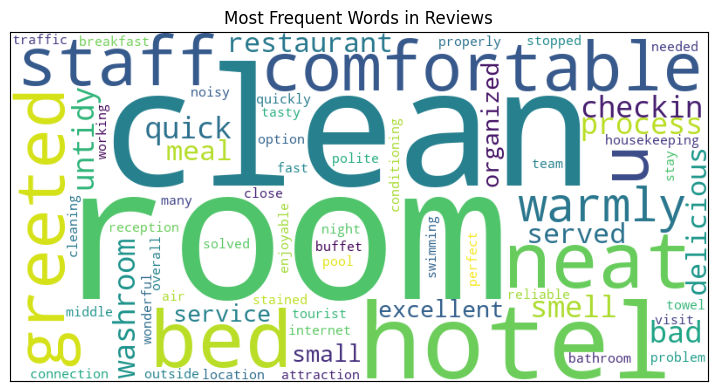

In [22]:
# -----------------------------
# Step 8: Visualize Frequent Words
# -----------------------------

all_reviews = " ".join(df["Clean_Review"])

word_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_reviews)

plt.figure(figsize=(9, 5))
plt.imshow(word_cloud)
plt.xticks([])
plt.yticks([])
plt.title("Most Frequent Words in Reviews")
plt.show()

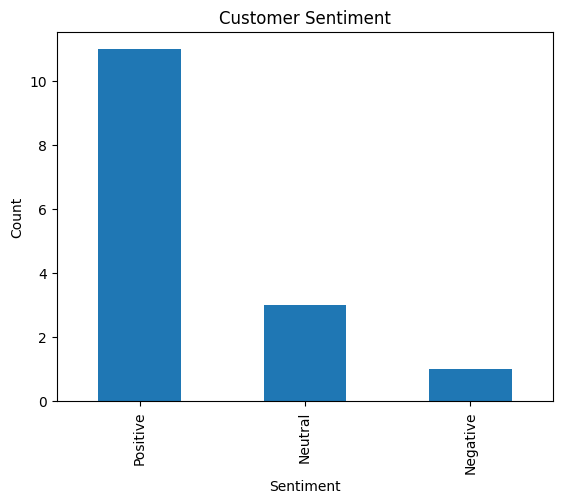

In [23]:
# -----------------------------
# Step 9: Sentiment Graph
# -----------------------------

df["Sentiment"].value_counts().plot(
    kind="bar",
    title="Customer Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [25]:
# -----------------------------
# Step 9: Add Actual Sentiments
# -----------------------------

df["Actual"] = [
    "Positive",
    "Positive",
    "Negative",
    "Positive",
    "Positive",
    "Negative",
    "Positive",
    "Positive",
    "Negative",
    "Positive",
    "Negative",
    "Negative",
    "Positive",
    "Negative",
    "Positive"
]

print(df[["Review", "Actual", "Sentiment"]])

                                               Review    Actual Sentiment
0   The hotel room was neat and the bed was very c...  Positive  Positive
1   Staff greeted us warmly and the check-in proce...  Positive  Positive
2        The washroom was untidy and had a bad smell.  Negative  Negative
3   The restaurant served delicious meals with exc...  Positive  Positive
4    The room was small but very clean and organized.  Positive  Positive
5       Housekeeping did not clean the room properly.  Negative  Positive
6   The hotel location was perfect and close to to...  Positive  Positive
7      The internet connection was fast and reliable.  Positive  Positive
8   The air conditioning stopped working in the mi...  Negative   Neutral
9   The reception team was polite and solved our p...  Positive  Positive
10       The breakfast buffet had many tasty options.  Negative  Positive
11     The room was noisy because of traffic outside.  Negative   Neutral
12         The swimming pool was clean

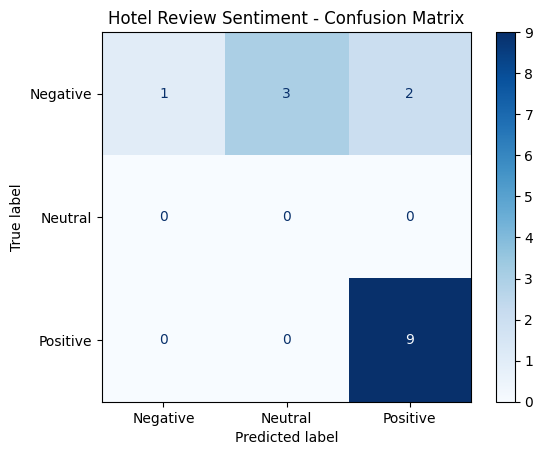

In [26]:
# -----------------------------
# Step 10: Confusion Matrix
# -----------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    df["Actual"],
    df["Sentiment"],
    labels=labels
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display.plot(cmap="Blues")
plt.title("Hotel Review Sentiment - Confusion Matrix")
plt.show()